# ⚡ Phase 5 — CNN-GRU & Model Comparison

This notebook:
- Trains the lightweight CNN-GRU model (MobileNetV3 + GRU)
- Compares CNN Baseline vs CNN-LSTM vs CNN-GRU
- Plots accuracy, inference speed, and parameter count

In [2]:
import sys, os
sys.path.insert(0, "../src")
import torch, torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from torch.optim import Adam
from tqdm.auto import tqdm
import pandas as pd, matplotlib.pyplot as plt, numpy as np, time

from utils import set_seed, get_device, CLASS_NAMES, plot_training_curves
from dataset import get_dataloader
from model import CNNGRU, get_model

set_seed(42)
device = get_device()


c:\Users\Abhinav\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU | VRAM: 6.4 GB


In [4]:
BATCH_SIZE, EPOCHS, LR = 8, 20, 1e-4
DATA_ROOT = "../data/raw"

train_loader, _ = get_dataloader(DATA_ROOT, "train", BATCH_SIZE, num_workers=4)
val_loader,   _ = get_dataloader(DATA_ROOT, "val",   BATCH_SIZE, num_workers=4)

# ── Train GRU ────────────────────────────────────────────
model = CNNGRU(num_classes=21, hidden_size=256).to(device)
print(f"CNN-GRU params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scaler = GradScaler()

gru_train_accs, gru_val_accs = [], []
best = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_c, t_t = 0, 0
    for frames, labels, _ in tqdm(train_loader, desc=f"E{epoch:02d}", leave=False):
        frames, labels = frames.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            out = model(frames); loss = criterion(out, labels)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        t_c += (out.argmax(1) == labels).sum().item(); t_t += labels.size(0)
    model.eval()
    v_c, v_t = 0, 0
    with torch.no_grad():
        for frames, labels, _ in val_loader:
            frames, labels = frames.to(device), labels.to(device)
            with autocast():
                out = model(frames)
            v_c += (out.argmax(1) == labels).sum().item(); v_t += labels.size(0)
    ta, va = 100*t_c/t_t, 100*v_c/v_t
    gru_train_accs.append(ta); gru_val_accs.append(va)
    print(f"E{epoch:02d} TAcc={ta:.1f}% VAcc={va:.1f}%")
    if va > best:
        best = va
        torch.save(model.state_dict(), "../models/saved/cnn_gru_best.pth")

print(f"\n✅ CNN-GRU Best Val Acc: {best:.2f}%")


  ✅ Loaded 21 class names from lable.txt
  [train] 939 videos | 21 classes | from train/
  ✅ Loaded 21 class names from lable.txt
  [val] 194 videos | 21 classes | from val/


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_21608\874787810.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


CNN-GRU params: 3,401,525


E01:   0%|          | 0/118 [00:00<?, ?it/s]C:\Users\Abhinav\AppData\Local\Temp\ipykernel_21608\874787810.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\Abhinav\AppData\Local\Temp\ipykernel_21608\874787810.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


E01 TAcc=14.7% VAcc=21.6%


...

E16 TAcc=87.6% VAcc=40.7%


E17 TAcc=89.7% VAcc=40.7%


E18 TAcc=89.9% VAcc=40.2%


E19 TAcc=91.4% VAcc=44.3%


E20 TAcc=94.5% VAcc=43.3%

✅ CNN-GRU Best Val Acc: 44.33%


In [5]:
# ── Model Comparison Table ───────────────────────────────
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

def infer_time(m, device, n=10):
    x = torch.randn(1, 20, 3, 224, 224).to(device)
    m.eval()
    with torch.no_grad():
        t0 = time.time()
        for _ in range(n): m(x)
        return (time.time() - t0) / n * 1000  # ms

results = {}
for name in ["cnn_baseline", "cnn_lstm", "cnn_gru"]:
    try:
        m = get_model(name, num_classes=21).to(device)
        ckpt_path = f"../models/saved/{name}_best.pth"
        if os.path.exists(ckpt_path):
            ckpt = torch.load(ckpt_path, map_location=device)
            m.load_state_dict(ckpt.get("model_state_dict", ckpt), strict=False)
        params = count_params(m)
        speed = infer_time(m, device)
        results[name] = {"params": f"{params/1e6:.1f}M", "infer_ms": f"{speed:.1f}"}
    except Exception as e:
        results[name] = {"params": "N/A", "infer_ms": "N/A", "note": str(e)}

comp_df = pd.DataFrame(results).T
comp_df.index.name = "Model"
print("\n📊 Model Comparison:")
print(comp_df.to_string())


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_21608\961213860.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)
d:\Downl


📊 Model Comparison:
             params infer_ms                                                            note
Model                                                                                       
cnn_baseline  24.6M     67.6                                                             NaN
cnn_lstm        N/A      N/A  input must have the type torch.float32, got type torch.float16
cnn_gru        3.4M     18.3                                                             NaN


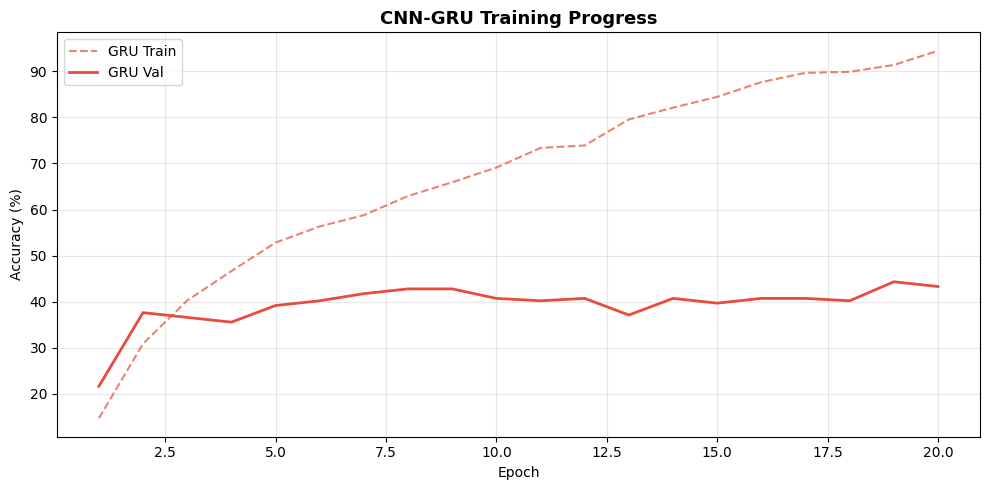

✅ Comparison complete!


In [6]:
# ── Visual Comparison ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
epochs_range = range(1, EPOCHS + 1)
ax.plot(epochs_range, gru_train_accs, "--", label="GRU Train", color="#e74c3c", alpha=0.7)
ax.plot(epochs_range, gru_val_accs, "-", label="GRU Val", color="#e74c3c", linewidth=2)
ax.set_title("CNN-GRU Training Progress", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/plots/cnn_gru_curves.png", dpi=150)
plt.show()
print("✅ Comparison complete!")
